# Endpoint Process Anomaly Detection

Rank unusual endpoint processes with a multivariate distance model trained on a clean baseline.

**Safety and scope:** This project uses synthetic, non-sensitive telemetry for defensive analytics. It does not perform exploitation or execute malicious content.

## Goal

Implement Mahalanobis-distance anomaly scoring and evaluate precision among the highest-ranked processes.


## Setup

The notebook is deterministic, runs offline, and implements the core analytical method directly with NumPy and Pandas so the modeling logic remains inspectable.


In [1]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 120)


## Steps

### 1. Generate process telemetry


In [2]:
normal_count = 700
suspicious_count = 55

normal = pd.DataFrame({
    "command_length": rng.normal(42, 13, normal_count).clip(5),
    "child_processes": rng.poisson(1.2, normal_count),
    "network_connections": rng.poisson(0.9, normal_count),
    "unsigned_binary": rng.binomial(1, 0.05, normal_count),
    "rare_path": rng.binomial(1, 0.04, normal_count),
    "encoded_marker": rng.binomial(1, 0.015, normal_count),
    "suspicious": 0,
})
suspicious = pd.DataFrame({
    "command_length": rng.normal(145, 28, suspicious_count).clip(30),
    "child_processes": rng.poisson(4.8, suspicious_count),
    "network_connections": rng.poisson(6.0, suspicious_count),
    "unsigned_binary": rng.binomial(1, 0.72, suspicious_count),
    "rare_path": rng.binomial(1, 0.68, suspicious_count),
    "encoded_marker": rng.binomial(1, 0.58, suspicious_count),
    "suspicious": 1,
})
process_events = pd.concat([normal, suspicious], ignore_index=True)
process_events = process_events.iloc[rng.permutation(len(process_events))].reset_index(drop=True)

print("Process count:", len(process_events))
print("Suspicious rate:", round(process_events["suspicious"].mean(), 3))
print(process_events.sample(6, random_state=SEED).round(2).to_string(index=False))


Process count: 755
Suspicious rate: 0.073
 command_length  child_processes  network_connections  unsigned_binary  rare_path  encoded_marker  suspicious
          47.02                2                    1                0          0               0           0
          46.48                1                    1                0          0               0           0
          18.20                0                    5                0          0               0           0
          28.06                1                    0                0          1               0           0
          50.65                0                    1                0          0               0           0
         117.21                4                    9                1          0               1           1


### 2. Fit a clean-baseline anomaly model


In [3]:
feature_names = [column for column in process_events.columns if column != "suspicious"]
baseline = process_events[process_events["suspicious"] == 0][feature_names].to_numpy(float)
all_values = process_events[feature_names].to_numpy(float)

baseline_mean = baseline.mean(axis=0)
covariance = np.cov(baseline, rowvar=False) + np.eye(len(feature_names)) * 0.05
inverse_covariance = np.linalg.pinv(covariance)
centered = all_values - baseline_mean
anomaly_score = np.sqrt(np.einsum("ij,jk,ik->i", centered, inverse_covariance, centered))

ranked_processes = process_events.copy()
ranked_processes["anomaly_score"] = anomaly_score
ranked_processes = ranked_processes.sort_values("anomaly_score", ascending=False)
review_budget = suspicious_count
precision_at_budget = ranked_processes.head(review_budget)["suspicious"].mean()
baseline_p99 = float(np.quantile(anomaly_score[process_events["suspicious"].to_numpy() == 0], 0.99))

print("99th percentile clean-baseline score:", round(baseline_p99, 3))
print("Precision at review budget:", round(precision_at_budget, 3))
print("\nHighest-ranked processes:")
print(ranked_processes.head(10).round(3).to_string(index=False))


99th percentile clean-baseline score: 4.612
Precision at review budget: 1.0

Highest-ranked processes:
 command_length  child_processes  network_connections  unsigned_binary  rare_path  encoded_marker  suspicious  anomaly_score
        185.624                7                   14                1          1               1           1         18.938
        215.980                5                    4                0          1               1           1         15.068
        192.315                7                    7                1          1               0           1         14.803
        187.059                6                    5                1          1               1           1         13.988
        176.494                8                    5                1          1               1           1         13.935
        166.928                3                   10                0          0               1           1         13.869
        170.797       

## Visual Insights & ML Extension

The original transparent method remains intact. This extension adds an explicit visual story, a stronger scikit-learn benchmark, and analyst-focused interpretation. All evaluation uses held-out or label-free synthetic examples as appropriate.

**Reading the results:** model scores describe this generated dataset only. They are not production performance claims and should not replace temporal validation, calibration, drift checks, or human review.


                  average_precision  roc_auc
Mahalanobis                   1.000    1.000
Isolation forest              0.992    0.999

Analyst takeaways:
- Mahalanobis ranks the simulated suspicious processes best by average precision.
- Isolation forest improves on a single global-distance assumption by modeling nonlinear partitions across 6 features.
- Production baselines should be segmented by host role and signed-software inventory to reduce false positives.


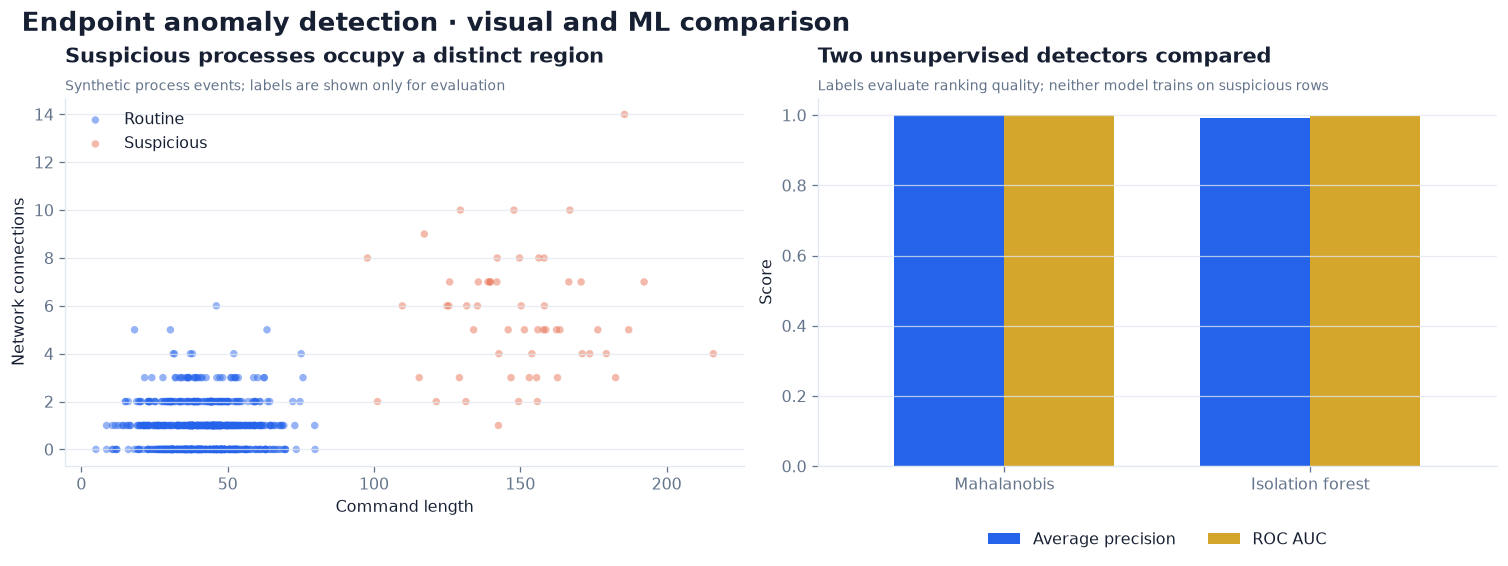

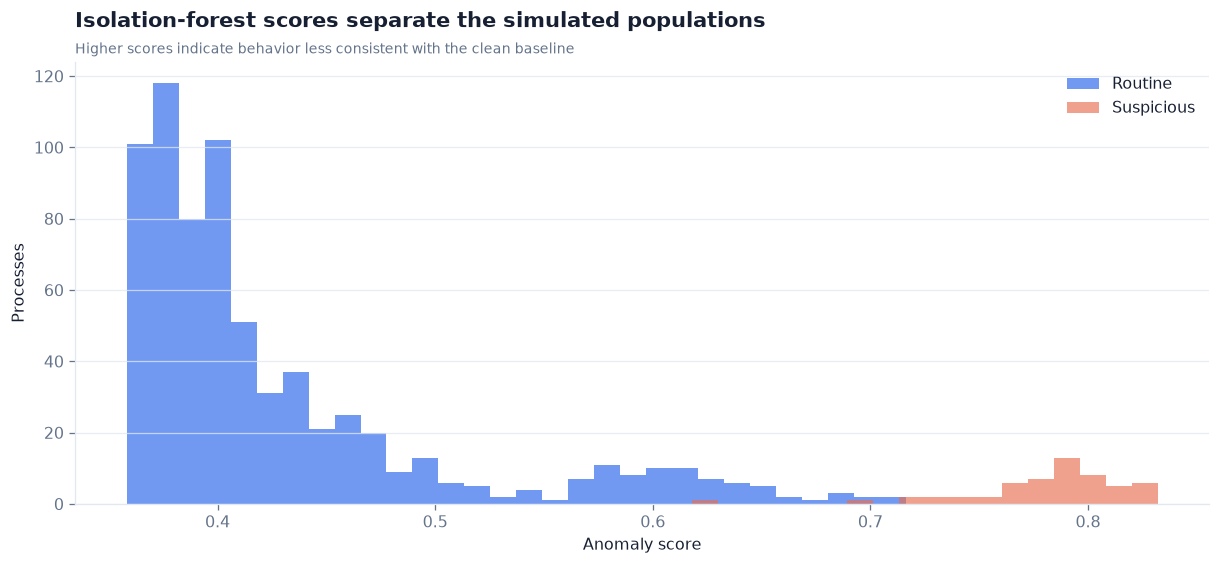

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 42)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def binary_model_comparison(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.28,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows = []
    probabilities = {}
    fitted = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

endpoint_features = process_events.drop(columns="suspicious").select_dtypes(include=[np.number])
endpoint_labels = process_events["suspicious"].to_numpy(int)
normal_features = endpoint_features[endpoint_labels == 0]
endpoint_scaler = StandardScaler().fit(normal_features)
endpoint_scaled = endpoint_scaler.transform(endpoint_features)
normal_scaled = endpoint_scaler.transform(normal_features)

isolation_model = IsolationForest(
    n_estimators=180,
    contamination=float(endpoint_labels.mean()),
    random_state=SEED,
    n_jobs=1,
).fit(normal_scaled)
isolation_score = -isolation_model.score_samples(endpoint_scaled)
mahalanobis_score = ranked_processes.sort_index()["anomaly_score"].to_numpy()
anomaly_comparison = pd.DataFrame({
    "average_precision": [
        average_precision_score(endpoint_labels, mahalanobis_score),
        average_precision_score(endpoint_labels, isolation_score),
    ],
    "roc_auc": [
        roc_auc_score(endpoint_labels, mahalanobis_score),
        roc_auc_score(endpoint_labels, isolation_score),
    ],
}, index=["Mahalanobis", "Isolation forest"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for class_value, color, name in [(0, PALETTE["blue"], "Routine"), (1, PALETTE["orange"], "Suspicious")]:
    subset = process_events[process_events["suspicious"] == class_value]
    axes[0].scatter(subset["command_length"], subset["network_connections"], s=22, alpha=0.48, color=color, edgecolors="none", label=name)
axes[0].legend(frameon=False)
polish_axis(axes[0], "Suspicious processes occupy a distinct region", "Synthetic process events; labels are shown only for evaluation", "Command length", "Network connections")

anomaly_display = anomaly_comparison.rename(columns={
    "average_precision": "Average precision",
    "roc_auc": "ROC AUC",
})
anomaly_display.plot(kind="bar", ax=axes[1], color=[PALETTE["blue"], PALETTE["gold"]], width=0.72)
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
polish_axis(axes[1], "Two unsupervised detectors compared", "Labels evaluate ranking quality; neither model trains on suspicious rows", "", "Score")
fig.suptitle("Endpoint anomaly detection · visual and ML comparison", fontsize=16, fontweight="bold", x=0.01, ha="left")

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
ax.hist(isolation_score[endpoint_labels == 0], bins=30, alpha=0.65, color=PALETTE["blue"], label="Routine")
ax.hist(isolation_score[endpoint_labels == 1], bins=18, alpha=0.65, color=PALETTE["orange"], label="Suspicious")
ax.legend(frameon=False)
polish_axis(ax, "Isolation-forest scores separate the simulated populations", "Higher scores indicate behavior less consistent with the clean baseline", "Anomaly score", "Processes")

best_detector = anomaly_comparison["average_precision"].idxmax()
print(anomaly_comparison.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- {best_detector} ranks the simulated suspicious processes best by average precision.")
print(f"- Isolation forest improves on a single global-distance assumption by modeling nonlinear partitions across {endpoint_features.shape[1]} features.")
print("- Production baselines should be segmented by host role and signed-software inventory to reduce false positives.")


## Checks


In [5]:
assert np.isfinite(anomaly_score).all()
assert precision_at_budget >= 0.85
assert ranked_processes["anomaly_score"].is_monotonic_decreasing
assert ranked_processes.head(10)["suspicious"].mean() >= 0.9
print("Checks passed: finite scores, high top-queue precision, and correctly ordered anomalies.")


Checks passed: finite scores, high top-queue precision, and correctly ordered anomalies.


## Next Steps

        - Build separate baselines by host role and operating system.
- Add signer, parent-child, prevalence, and command-line token features.
- Use analyst dispositions to tune the ranking threshold.
